### Monopólios Esportivos

**​A Pergunta:** Quais esportes são dominados por um único país?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Inicia criando o data frame que vai ler os dados dos atletas

In [2]:
df_atleta = pd.read_csv('athlete_events_limpo.csv', encoding='utf-8')
df_atleta['Medal'] = df_atleta['Medal'].fillna('0')
display(df_atleta.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0
2,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,0
3,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,0
4,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,0


Agrupa os paises a partir do NOC e do esporte, contando a quantidade de medalhas de cada tipo (Ouro, Prata, Bronze) e preenchendo os valores faltantes (quem não tem medalha) com 0  e em seguida, agrupa usando o NOC e o sport para contar o número total de atletas para poder criar um novo data frame que vai unir o data frame com a quatidade de medalhas de cada tipo e o total de atletas.

In [3]:
df_medalhas = df_atleta.groupby(['NOC', 'Sport'])['Medal'].value_counts().unstack(fill_value=0) 

df_total = df_atleta.groupby(['NOC', 'Sport']).size().reset_index(name='Total_Atletas') 

df_simples = pd.merge(df_total, df_medalhas, on=['NOC', 'Sport'])

#display(df_simples.head())
#display(df_total.head())
#display(df_medalhas.head())

Cria um dataframe que vai receber o agrupamento de países a partir do NOC, isso vai fazer com que cada país seja uma única linha, e as colunas de Total_Atletas, Gold, Silver e Bronze sejam somadas para cada país. Depois, seleciona os 15 paises que mais levaram atletas e em seguida cria o gráfico usando os países no x, a quantidade no y para analisar o Total_Atletas e cada tipo de medalha.

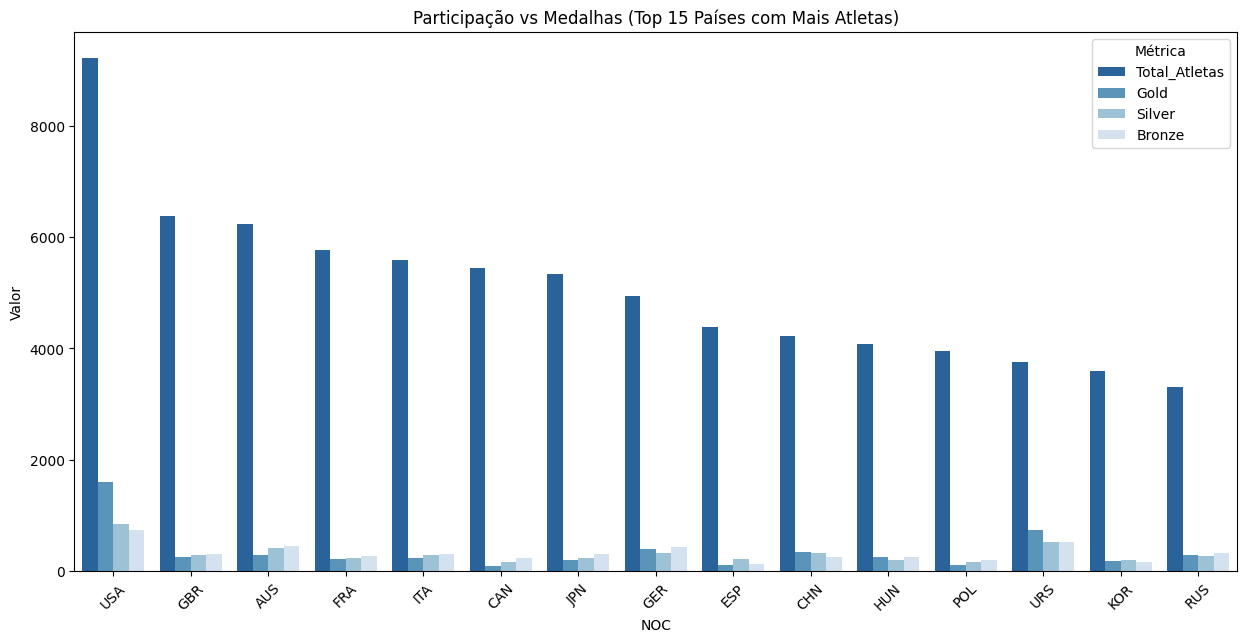

In [4]:
df_agrupado = df_simples.groupby('NOC').agg({
    'Total_Atletas': 'sum',
    'Gold': 'sum',
    'Silver': 'sum',
    'Bronze': 'sum'
}).reset_index()

df_top = df_agrupado.nlargest(15, 'Total_Atletas')

df_plot = df_top.melt(id_vars=['NOC'], 
                      value_vars=['Total_Atletas', 'Gold', 'Silver', 'Bronze'],
                      var_name='Métrica', 
                      value_name='Valor')

plt.figure(figsize=(15, 7))
sns.barplot(data=df_plot, x='NOC', y='Valor', hue='Métrica', palette='Blues_r')
plt.title('Participação vs Medalhas (Top 15 Países com Mais Atletas)')
plt.xticks(rotation=45) 
plt.show()

##### Qual a relação entre Total de Atletas e Medalhas?

Cria um gráfico de dispersão para cada par de variáveis. (Sem a paleta que usamos pois ia ficar confuso de visualizar)

In [12]:
top_15_nocs = df_top['NOC'].unique()
df_historico_top = df_simples[df_simples['NOC'].isin(top_15_nocs)]

In [13]:
display(df_historico_top.head())

,NOC,Sport,Total_Atletas,0,Bronze,Gold,Silver
129,AUS,Archery,73,68,4,1,0
130,AUS,Athletics,756,710,13,9,24
131,AUS,Badminton,57,57,0,0,0
132,AUS,Baseball,68,44,0,0,24
133,AUS,Basketball,250,190,24,0,36


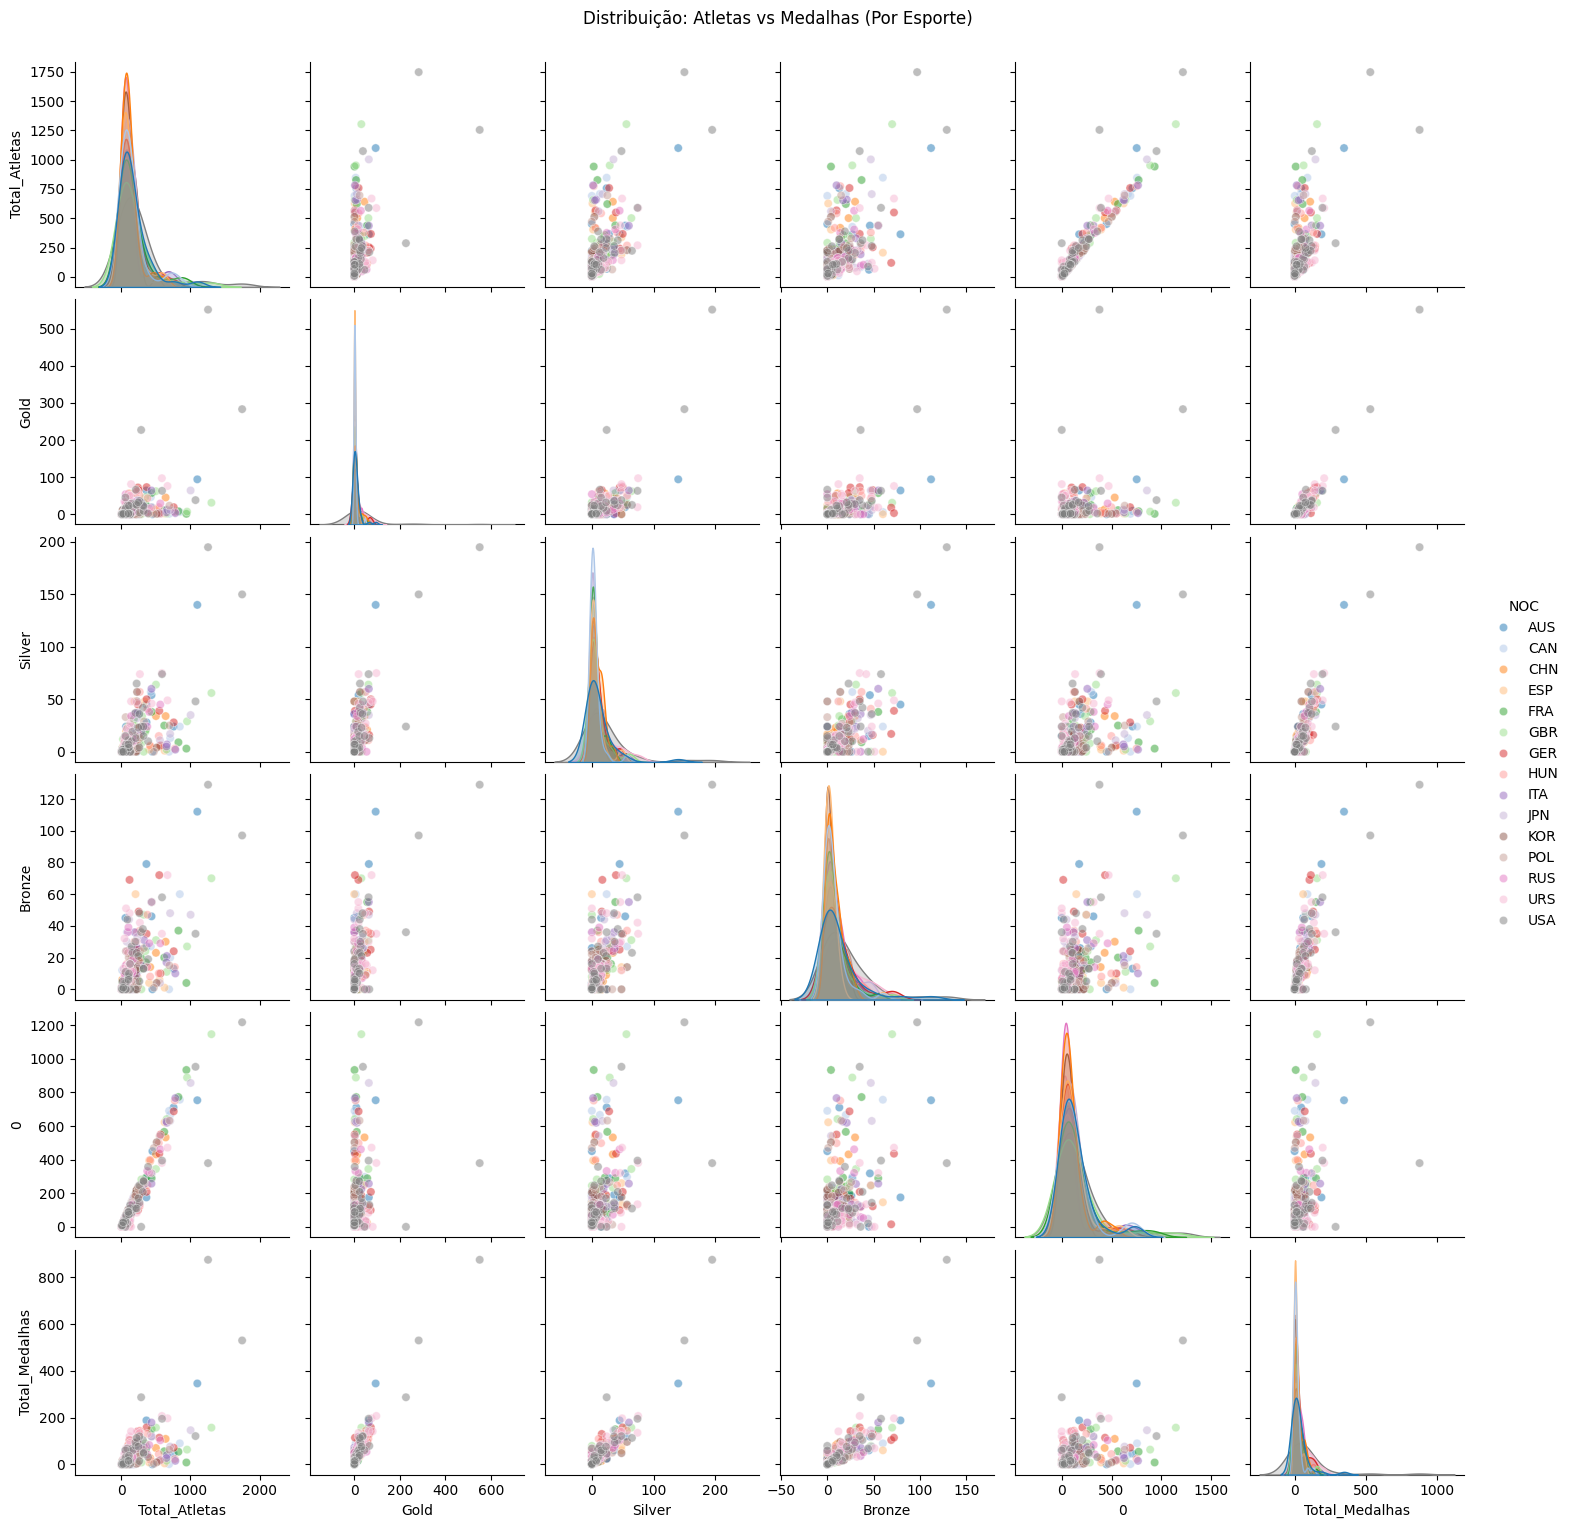

In [17]:
# 1. Criamos a coluna Total_Medalhas somando as parciais
df_historico_top['Total_Medalhas'] = df_historico_top['Gold'] + df_historico_top['Silver'] + df_historico_top['Bronze']


# 3. Geramos o pairplot com a coluna nova
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.pairplot(data=df_historico_top, 
                 vars=['Total_Atletas', 'Gold', 'Silver', 'Bronze', '0', 'Total_Medalhas'], 
                 hue="NOC", 
                 palette="tab20",
                 diag_kind="kde",
                 plot_kws={'alpha': 0.5}) # Transparência para ver pontos sobrepostos

g.fig.suptitle('Distribuição: Atletas vs Medalhas (Por Esporte)', y=1.02)
plt.show()

Os gráficos que cortam a diagonal principal são estimativas de densidade (KDE). Eles mostram onde os dados de cada país se concentram. Picos altos e estreitos significam que os números são consistentes, pois o eixo Y mostra que o valor é frequente e o eixo X curto indica baixa variância. Já uma curva baixa no Y ocorre porque existem resultados diferentes a cada registro, e se ela for larga no X, indica alta variância. No caso da França (verde), a partir das análises, podemos ver que ela é constante quanto às medalhas, enquanto o azul (EUA) é mais inconstante e variável.

Nos gráficos de dispersão (todos os outros), analisamos a correlação entre as variáveis. Percebemos que o Total de atletas é a principal variável das medalhas (mais atletas = mais medalhas); a inclinação dos pontos representa a eficácia de um país. A maioria dos países fica agrupada, o que significa que têm desempenho similar. Os EUA se destacam como um outlier constante, mantendo uma trajetória de crescimento que se distancia das demais potências conforme o volume de atletas aumenta

##### Em qual esporte cada pais mais tem medalhas?

Cria uma nova coluna que tem o total de medalhas no geral, após isso busca o esporte com mais medalhas de cada país. Calcula taxa de sucesso do esporte com mais medalhas usando a formula: $$Eficiência = \left( \frac{\text{Total de Medalhas}}{\text{Total de Atletas}} \right) \times 100$$
Ordena pelos 20 paises que mais tem medalhas.

In [111]:
df_simples['Total_Medalhas'] = df_simples['Gold'] + df_simples['Silver'] + df_simples['Bronze']

idx = df_simples.groupby('NOC')['Total_Medalhas'].idxmax()
df_destaque = df_simples.loc[idx, ['NOC', 'Sport', 'Total_Medalhas', 'Total_Atletas']]

df_destaque['Eficiencia_%'] = (df_destaque['Total_Medalhas'] / df_destaque['Total_Atletas'] * 100).round(2)

display(df_destaque.sort_values(by='Total_Medalhas', ascending=False).head(20))

,NOC,Sport,Total_Medalhas,Total_Atletas,Eficiencia_%
2980,USA,Swimming,875,1254,69.78
154,AUS,Swimming,346,1099,31.48
2009,NED,Hockey,209,372,56.18
2921,URS,Gymnastics,207,587,35.26
1096,GDR,Rowing,184,205,89.76
1478,ITA,Fencing,179,436,41.06
2353,ROU,Rowing,175,349,50.14
1145,GER,Rowing,158,366,43.17
1047,GBR,Athletics,157,1303,12.05
979,FRA,Fencing,150,439,34.17


Pega os primeiros 20 paises que mais tem medalhas por esporte, cria uma coluna que tem o nome do país e o esporte que ele mais se destacou este sera o y do grafico que vamos criar. Criamos o gráfico usando a coluna que criamos no y e o total de medlahas no x e em seguida um for que vai mostrar a eficiencia no final da barra de cada pais e seu esporte de maior numero de medalhas. 

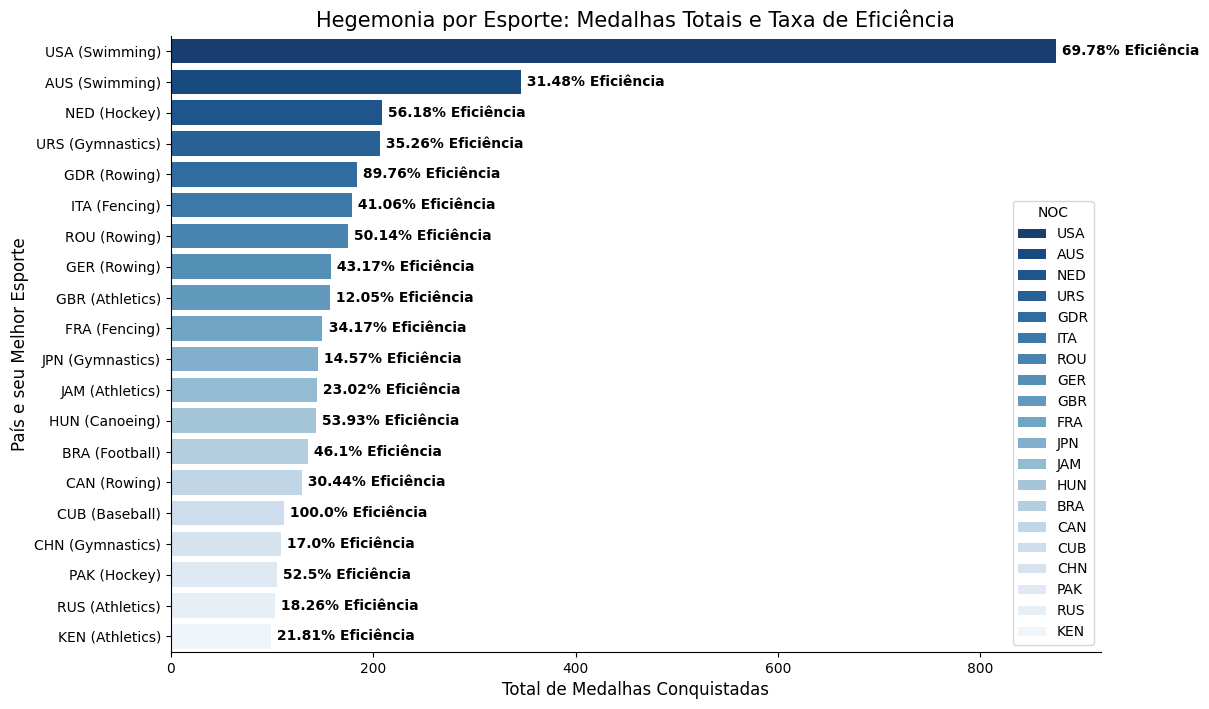

In [112]:
df_plot = df_destaque.sort_values(by='Total_Medalhas', ascending=False).head(20).copy() 
df_plot['Label'] = df_plot['NOC'] + ' (' + df_plot['Sport'] + ')' 

plt.figure(figsize=(12, 8))

ax = sns.barplot(data=df_plot,
                x='Total_Medalhas', 
                y='Label', 
                hue='NOC', 
                palette='Blues_r')

for i, (medals, eff) in enumerate(zip(df_plot['Total_Medalhas'], df_plot['Eficiencia_%'])):
    ax.text(medals + 1, i, f' {eff}% Eficiência', va='center', fontweight='bold', color='black')

plt.title('Hegemonia por Esporte: Medalhas Totais e Taxa de Eficiência', fontsize=15)
plt.xlabel('Total de Medalhas Conquistadas', fontsize=12)
plt.ylabel('País e seu Melhor Esporte', fontsize=12)
sns.despine()
plt.show()

##### Quais esportes tem mais medalhas?

Pega por esporte o total de medalhas e ordena do maior para o menor, pegando os 15 primeiros, cria um grafico de barras que analiza o total de medalhas por esporte

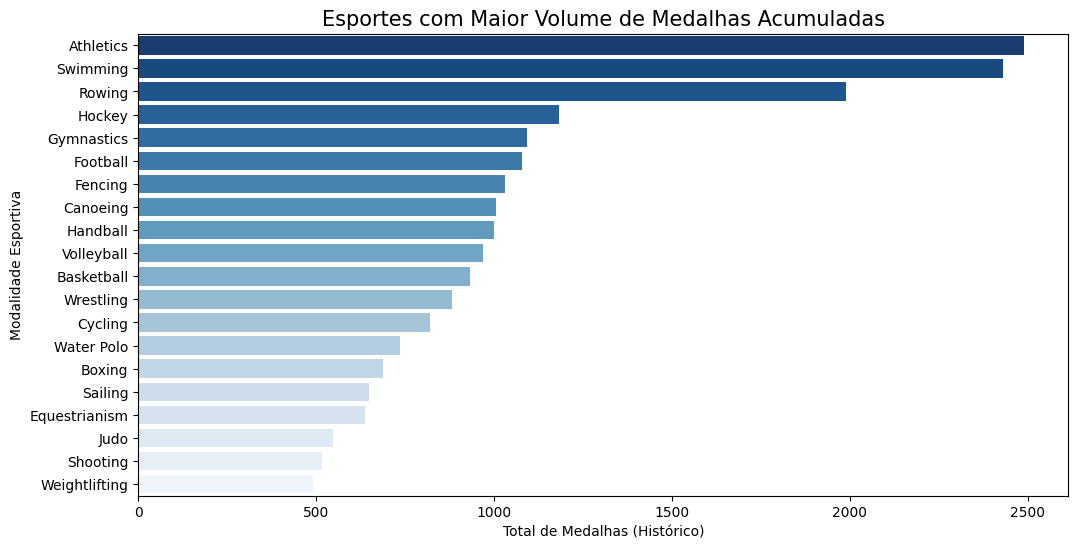

In [ ]:
df_esportes_top = df_simples.groupby('Sport')['Total_Medalhas'].sum().nlargest(20).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_esportes_top, 
            x='Total_Medalhas', 
            y='Sport', 
            hue='Sport', 
            palette='Blues_r')

plt.title('Esportes com Maior Número de Medalhas', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')
plt.show()

##### Quais esportes tem mais atletas?

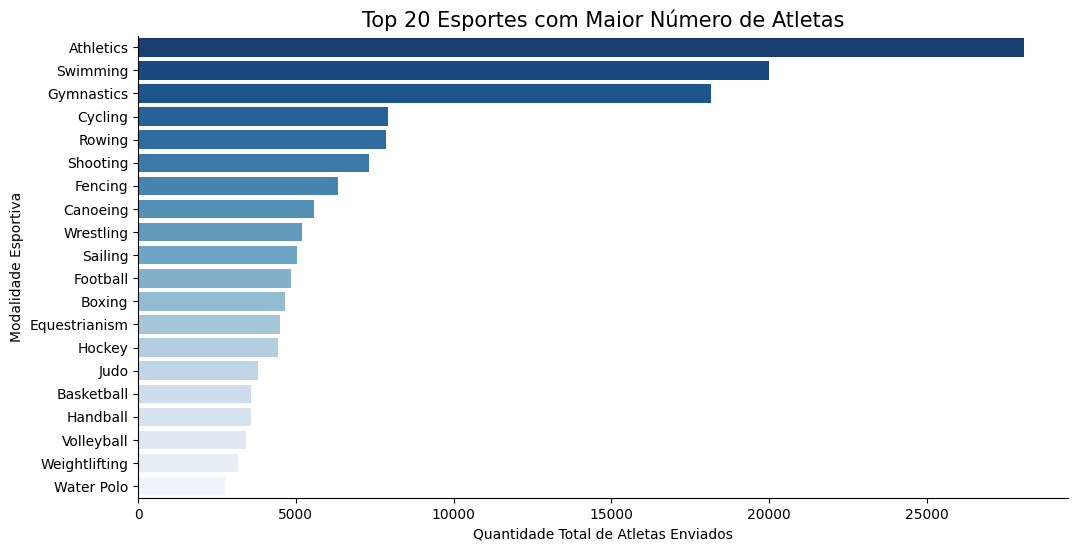

In [118]:
df_atletas_top = df_simples.groupby('Sport')['Total_Atletas'].sum().nlargest(20).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=df_atletas_top, 
            x='Total_Atletas', 
            y='Sport',
            hue='Sport', 
            palette='Blues_r') 

plt.title('Top 20 Esportes com Maior Número de Atletas', fontsize=15)
plt.xlabel('Quantidade Total de Atletas Enviados')
plt.ylabel('Modalidade Esportiva')

sns.despine()
plt.show()

##### Analise do Brasil

Filtra apenas o Brasil no dataframe geral e agrupa por cada esporte o total de medalhas.

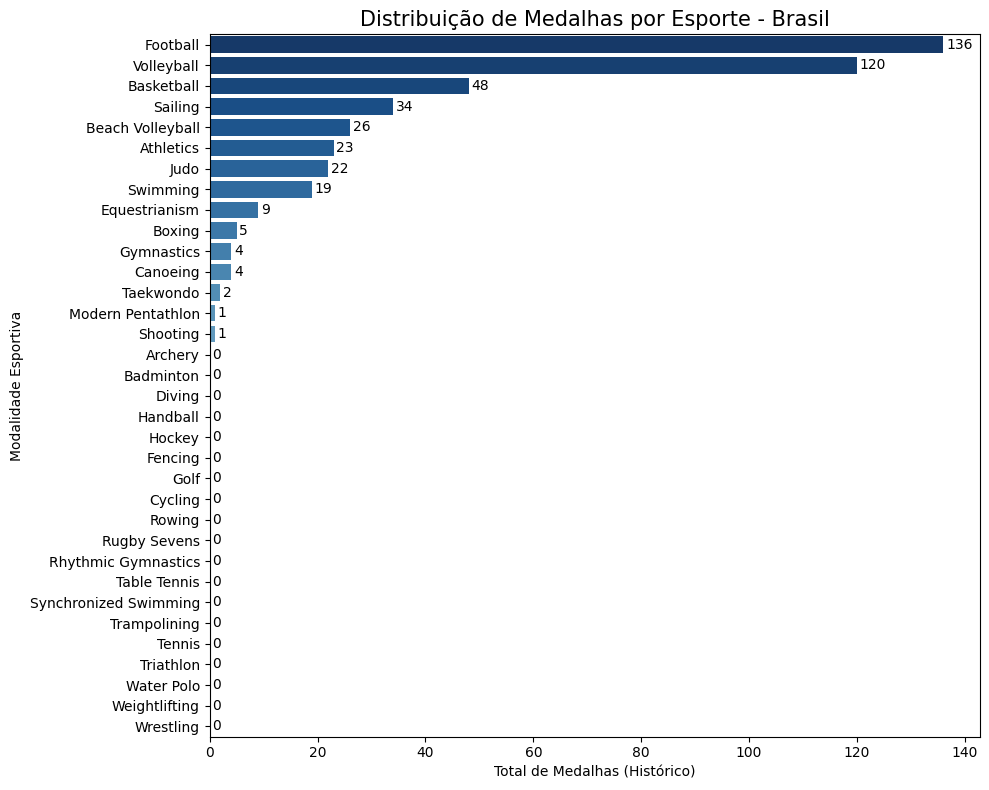

In [117]:
df_brasil = df_simples[df_simples['NOC'] == 'BRA']

df_bra_esportes = df_brasil.groupby('Sport')['Total_Medalhas'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_bra_esportes, 
    x='Total_Medalhas', 
    y='Sport',
    hue='Sport', 
    palette='Blues_r' 
)

plt.title('Distribuição de Medalhas por Esporte - Brasil', fontsize=15)
plt.xlabel('Total de Medalhas (Histórico)')
plt.ylabel('Modalidade Esportiva')


for i, v in enumerate(df_bra_esportes['Total_Medalhas']):
    plt.text(v + 0.5, i, str(int(v)), color='black', va='center')

plt.tight_layout()
plt.show()

#### Qual a porcentagem de medalhas de ouro ganhas por um único país em modalidades específicas?

Primeiro, calcula o total de ouros por esporte de todas as medalhas de ouro dadas e calcula os ouros agrupando por pais e esportes para calcular a porcentagem da dominancia usando a formula e evida divisao por zero: $$Dominância = \left( \frac{\text{Total de (medalhas do tipo) do País no Esporte}}{\text{Total de (medalhas do tipo) Históricos do Esporte}} \right) \times 100$$ depois filtra para pegar apenas os esportes com mais de 10 ouros totais e países com pelo menos 3 ouros para evitar um gráfico muito vazio.

**Ouro**

In [84]:
df_calc = df_simples.copy()

total_ouros_esporte = df_calc.groupby('Sport')['Gold'].sum()

df_dominancia = df_calc.groupby(['NOC', 'Sport'])['Gold'].sum().reset_index()

df_dominancia['Dominancia_%'] = df_dominancia.apply(
    lambda x: (x['Gold'] / total_ouros_esporte[x['Sport']] * 100) 
    if total_ouros_esporte[x['Sport']] > 0 else 0, axis=1
)

esportes_vivos = total_ouros_esporte[total_ouros_esporte > 10].index
df_plot = df_dominancia[
    (df_dominancia['Sport'].isin(esportes_vivos)) & 
    (df_dominancia['Gold'] >= 3)
].copy()

Cria o gráfico, que vai mostrar as 15 primeiras dominâncias, usando no eixo x a porcentagem da dominância e no y uma coluna que tem o nome do NOC e o esporte. Cria um for que vai adicionar o valor da dominancia em porcentagem no final de cada barra.

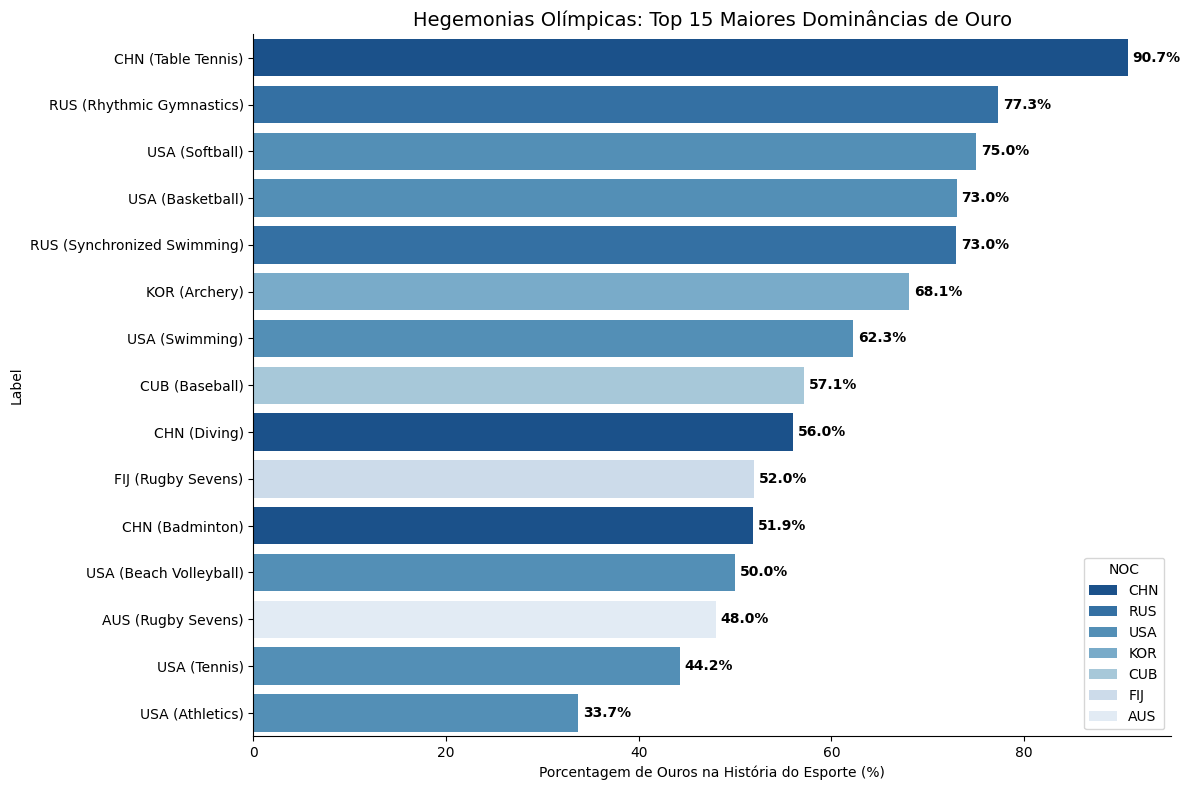

In [ ]:
df_plot = df_plot.sort_values('Dominancia_%', ascending=False).head(15)
df_plot['Label'] = df_dominancia['NOC'] + " (" + df_dominancia['Sport'] + ")"

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_plot, 
    x='Dominancia_%', 
    y=df_plot['Label'], 
    hue='NOC', 
    dodge=False,
    palette='Blues_r'
)

plt.title('Hegemonias Olímpicas: Top 15 Maiores Dominâncias de Ouro', fontsize=14)
plt.xlabel('Porcentagem de Ouros na História do Esporte (%)')

for i, v in enumerate(df_plot['Dominancia_%']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

**Prata**

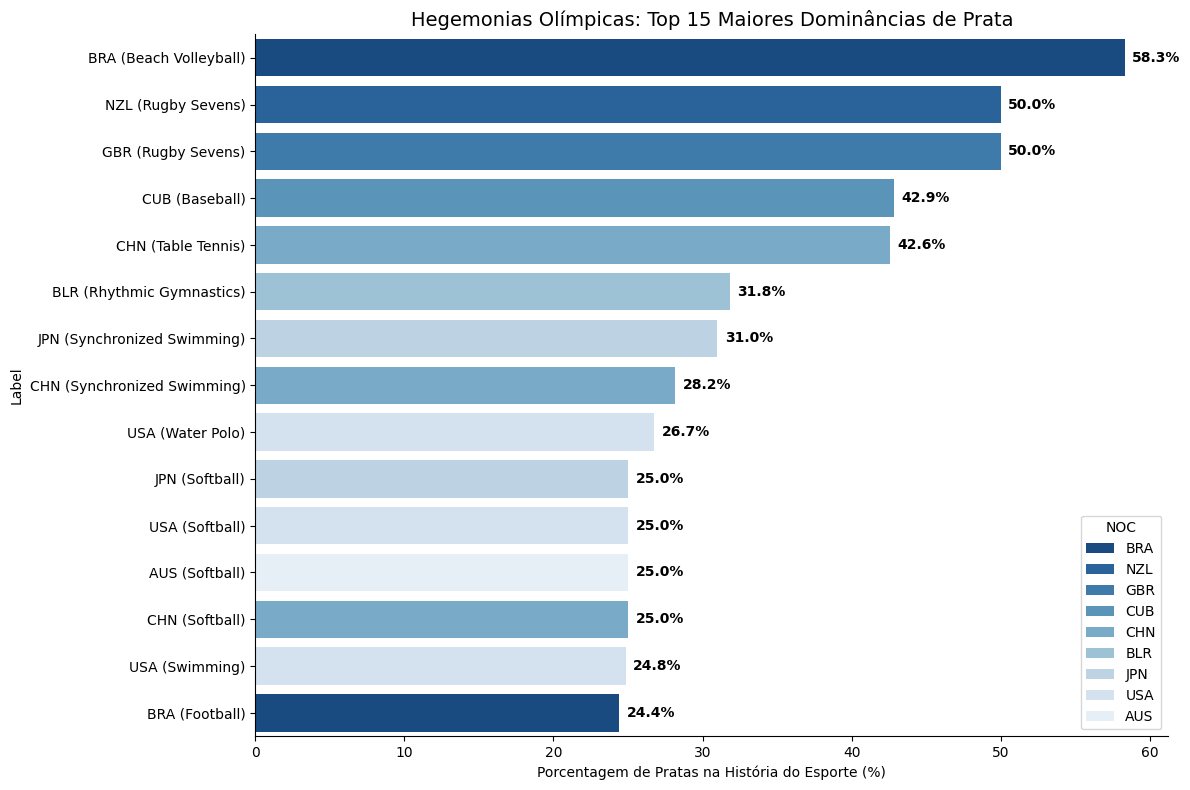

In [119]:
df_calc = df_simples.copy()

total_prata_esporte = df_calc.groupby('Sport')['Silver'].sum()

df_dominancia = df_calc.groupby(['NOC', 'Sport'])['Silver'].sum().reset_index()

df_dominancia['Dominancia_%'] = df_dominancia.apply(
    lambda x: (x['Silver'] / total_prata_esporte[x['Sport']] * 100) 
    if total_prata_esporte[x['Sport']] > 0 else 0, axis=1
)

esportes_vivos = total_prata_esporte[total_prata_esporte > 10].index
df_plot = df_dominancia[
    (df_dominancia['Sport'].isin(esportes_vivos)) & 
    (df_dominancia['Silver'] >= 3)
].copy()


df_plot = df_plot.sort_values('Dominancia_%', ascending=False).head(15)
df_plot['Label'] = df_dominancia['NOC'] + " (" + df_dominancia['Sport'] + ")"

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_plot, 
    x='Dominancia_%', 
    y=df_plot['Label'], 
    hue='NOC', 
    dodge=False,
    palette='Blues_r'
)

plt.title('Hegemonias Olímpicas: Top 15 Maiores Dominâncias de Prata', fontsize=14)
plt.xlabel('Porcentagem de Pratas na História do Esporte (%)')

for i, v in enumerate(df_plot['Dominancia_%']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

**Bronze**

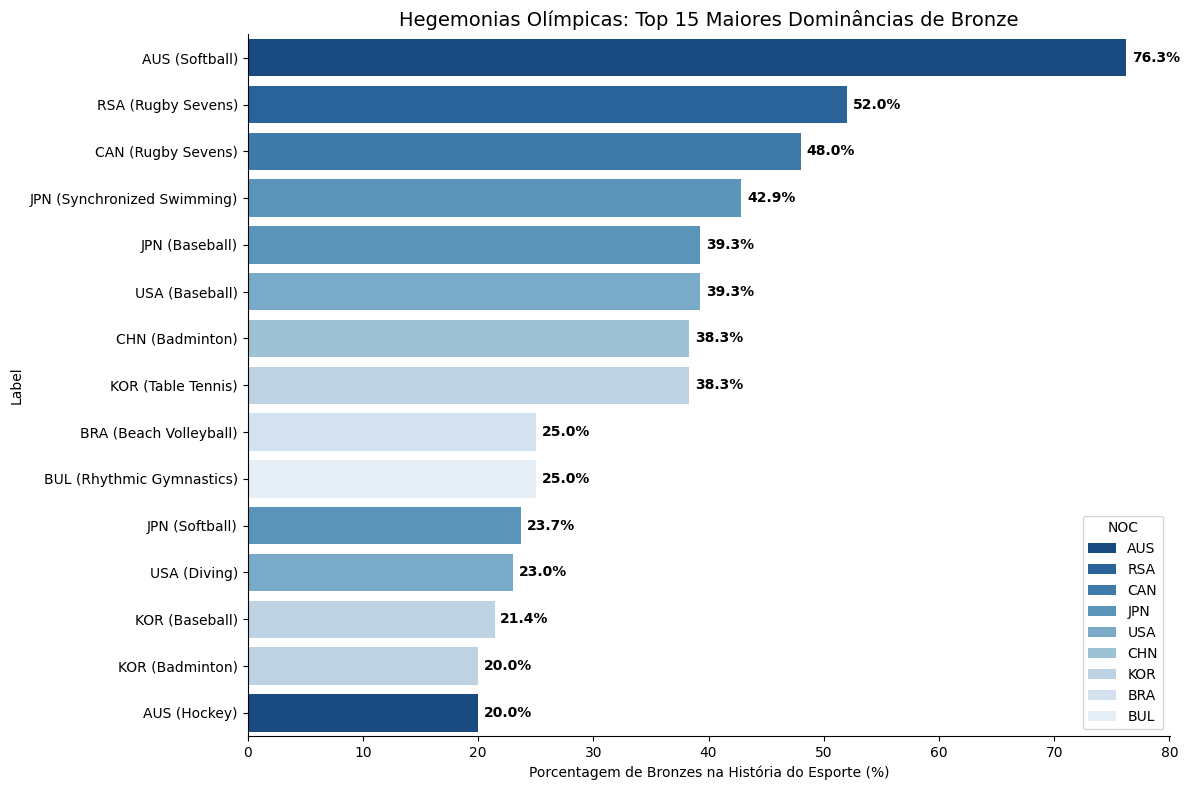

In [120]:
df_calc = df_simples.copy()

total_bronze_esporte = df_calc.groupby('Sport')['Bronze'].sum()

df_dominancia = df_calc.groupby(['NOC', 'Sport'])['Bronze'].sum().reset_index()

df_dominancia['Dominancia_%'] = df_dominancia.apply(
    lambda x: (x['Bronze'] / total_bronze_esporte[x['Sport']] * 100) 
    if total_bronze_esporte[x['Sport']] > 0 else 0, axis=1
)

esportes_vivos = total_bronze_esporte[total_bronze_esporte > 10].index
df_plot = df_dominancia[
    (df_dominancia['Sport'].isin(esportes_vivos)) & 
    (df_dominancia['Bronze'] >= 3)
].copy()


df_plot = df_plot.sort_values('Dominancia_%', ascending=False).head(15)
df_plot['Label'] = df_dominancia['NOC'] + " (" + df_dominancia['Sport'] + ")"

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=df_plot, 
    x='Dominancia_%', 
    y=df_plot['Label'], 
    hue='NOC', 
    dodge=False,
    palette='Blues_r'
)

plt.title('Hegemonias Olímpicas: Top 15 Maiores Dominâncias de Bronze', fontsize=14)
plt.xlabel('Porcentagem de Bronzes na História do Esporte (%)')

for i, v in enumerate(df_plot['Dominancia_%']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()